# Recommendation systems
## Adult Income Classification and Recommendation System

## Project objective

This project uses demographic and socioeconomic census data to predict
whether an individual's annual income exceeds $50,000.

A recommendation layer will then evaluate hypothetical changes in selected
actionable variables, such as education, occupation, work class, and working
hours, and identify changes associated with a higher predicted probability
of earning more than $50,000.

The recommendations represent statistical associations found in historical
data and should not be interpreted as causal or prescriptive financial advice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2325&path=adult-census-income.csv"

df = pd.read_csv(url)

In [3]:
print("Dataset shape:", df.shape)

display(df.head())

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [5]:
print("Column names:")
print(df.columns.tolist())

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 24


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education.num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital.status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.columns = df.columns.str.replace(".", "_", regex=False)

df.columns.tolist()

['age',
 'workclass',
 'fnlwgt',
 'education',
 'education_num',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital_gain',
 'capital_loss',
 'hours_per_week',
 'native_country',
 'income']

In [9]:
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [10]:
df = df.replace("?", np.nan)

In [11]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79


In [12]:
pd.crosstab(
    df["workclass"].isna(),
    df["occupation"].isna(),
    rownames=["workclass_missing"],
    colnames=["occupation_missing"]
)

occupation_missing,False,True
workclass_missing,,
False,30718,7
True,0,1836


In [13]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_removed = rows_before - len(df)

print("Rows before:", rows_before)
print("Duplicate rows removed:", rows_removed)
print("Rows after:", len(df))

Rows before: 32561
Duplicate rows removed: 24
Rows after: 32537


In [14]:
df["income"].value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [15]:
df["income_binary"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

In [16]:
df[["income", "income_binary"]].head()

,income,income_binary
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [17]:
df["income_binary"].value_counts(dropna=False)

income_binary
0    24698
1     7839
Name: count, dtype: int64

In [18]:
income_distribution = (
    df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

income_distribution

income
<=50K    75.91
>50K     24.09
Name: proportion, dtype: float64

### Initial data-quality findings

The dataset contained missing values encoded as `"?"`, which were not
recognized automatically as null values. These values were converted to
`NaN` for appropriate handling during preprocessing.

Leading and trailing spaces were removed from categorical variables, and
exact duplicate rows were removed.

The target variable was encoded as:

- `0`: annual income less than or equal to $50,000
- `1`: annual income greater than $50,000

The outcome is imbalanced, with approximately 76% of observations in the
`<=50K` category and 24% in the `>50K` category. Consequently, classification
accuracy alone may overstate model performance. Precision, recall, F1-score,
ROC-AUC, and the confusion matrix will also be evaluated.

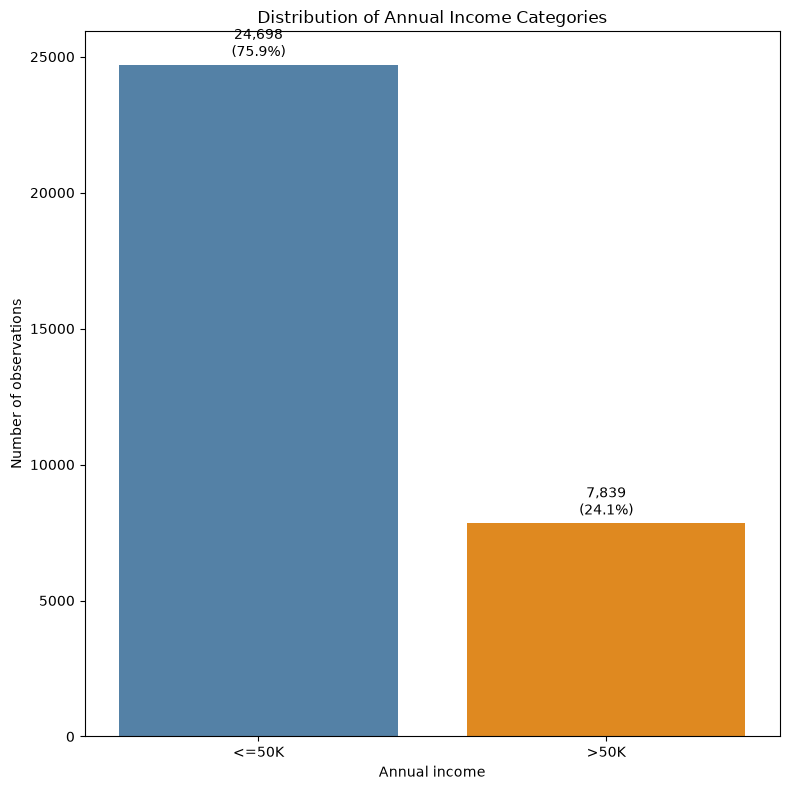

In [21]:
plt.figure(figsize=(8, 8
))

ax = sns.countplot(
    data=df,
    x="income",
    order=["<=50K", ">50K"],
    hue="income",
    palette=["steelblue", "darkorange"],
    legend=False
)

plt.title("Distribution of Annual Income Categories")
plt.xlabel("Annual income")
plt.ylabel("Number of observations")

total = len(df)

for container in ax.containers:
    labels = [
        f"{int(bar.get_height()):,}\n({bar.get_height() / total:.1%})"
        for bar in container
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

In [22]:
education_summary = (
    df.groupby(["education", "education_num"], observed=True)
    .agg(
        number_of_people=("income_binary", "size"),
        number_above_50k=("income_binary", "sum"),
        proportion_above_50k=("income_binary", "mean")
    )
    .reset_index()
    .sort_values("education_num")
)

education_summary

,education,education_num,number_of_people,number_above_50k,proportion_above_50k
13,Preschool,1,50,0,0.000000
3,1st-4th,2,166,6,0.036145
4,5th-6th,3,332,16,0.048193
5,7th-8th,4,645,40,0.062016
6,9th,5,514,27,0.052529
0,10th,6,933,62,0.066452
1,11th,7,1175,60,0.051064
2,12th,8,433,33,0.076212
11,HS-grad,9,10494,1674,0.159520
15,Some-college,10,7282,1386,0.190332


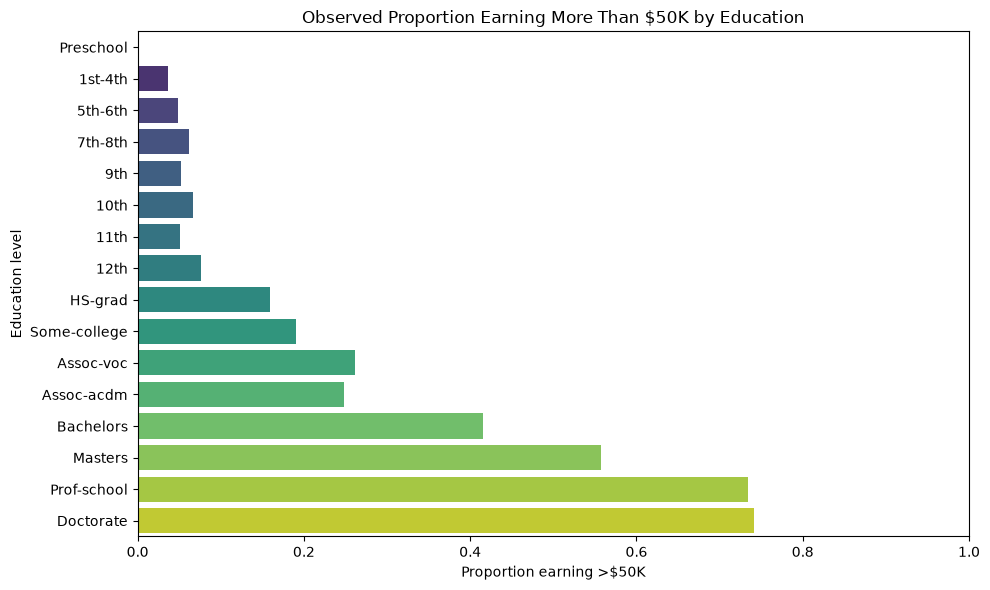

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_summary,
    x="proportion_above_50k",
    y="education",
    hue="education",
    palette="viridis",
    legend=False
)

plt.title("Observed Proportion Earning More Than $50K by Education")
plt.xlabel("Proportion earning >$50K")
plt.ylabel("Education level")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [24]:
occupation_summary = (
    df.groupby("occupation", dropna=False, observed=True)
    .agg(
        number_of_people=("income_binary", "size"),
        proportion_above_50k=("income_binary", "mean")
    )
    .reset_index()
    .sort_values("proportion_above_50k", ascending=False)
)

occupation_summary

,occupation,number_of_people,proportion_above_50k
3,Exec-managerial,4065,0.484133
9,Prof-specialty,4136,0.449226
10,Protective-serv,649,0.325116
12,Tech-support,927,0.305286
11,Sales,3650,0.269315
2,Craft-repair,4094,0.226917
13,Transport-moving,1597,0.200376
0,Adm-clerical,3768,0.134554
6,Machine-op-inspct,2000,0.124500
4,Farming-fishing,992,0.115927


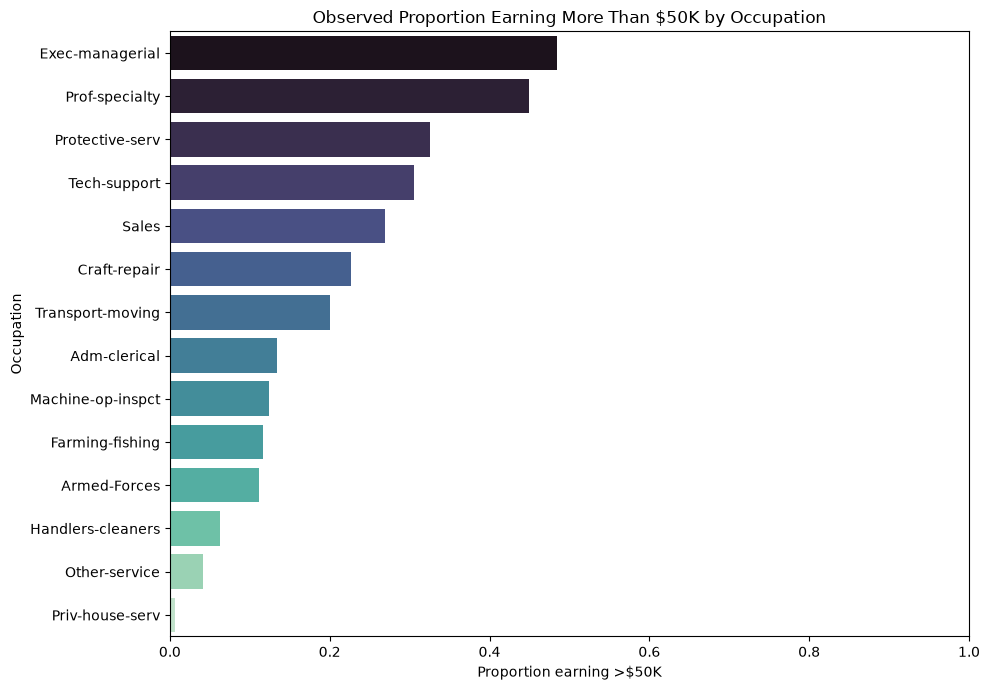

In [25]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=occupation_summary,
    x="proportion_above_50k",
    y="occupation",
    hue="occupation",
    palette="mako",
    legend=False
)

plt.title("Observed Proportion Earning More Than $50K by Occupation")
plt.xlabel("Proportion earning >$50K")
plt.ylabel("Occupation")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [26]:
numerical_summary = (
    df.groupby("income")[
        [
            "age",
            "education_num",
            "hours_per_week",
            "capital_gain",
            "capital_loss"
        ]
    ]
    .median()
    .round(1)
)

numerical_summary

,age,education_num,hours_per_week,capital_gain,capital_loss
income,,,,,
<=50K,34.0,9.0,40.0,0.0,0.0
>50K,44.0,12.0,40.0,0.0,0.0


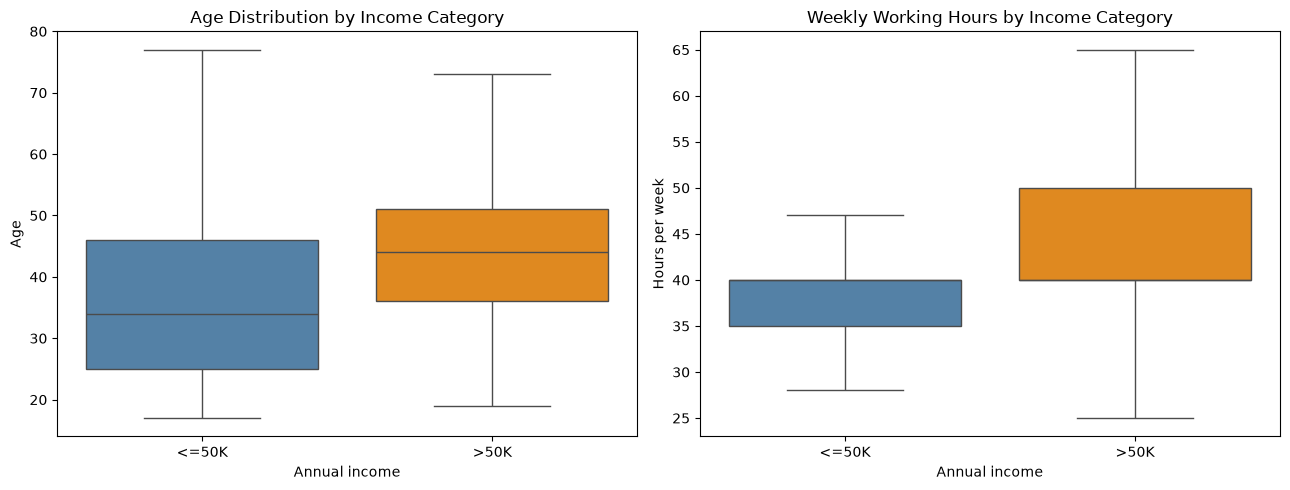

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=df,
    x="income",
    y="age",
    order=["<=50K", ">50K"],
    hue="income",
    palette=["steelblue", "darkorange"],
    legend=False,
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title("Age Distribution by Income Category")
axes[0].set_xlabel("Annual income")
axes[0].set_ylabel("Age")

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week",
    order=["<=50K", ">50K"],
    hue="income",
    palette=["steelblue", "darkorange"],
    legend=False,
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title("Weekly Working Hours by Income Category")
axes[1].set_xlabel("Annual income")
axes[1].set_ylabel("Hours per week")

plt.tight_layout()
plt.show()

### Socioeconomic patterns

Higher education levels were associated with a greater observed proportion
of income above $50,000. The largest proportions were observed among people
with professional-school and doctoral education.

Income also varied substantially across occupations. Executive-managerial
and professional-specialty occupations had the largest observed proportions
above $50,000, while private-household and other-service occupations had the
lowest.

Adults in the higher-income category were generally older. Although both
income groups had a median work week of 40 hours, the overall distribution
was shifted toward longer working hours in the higher-income group.

These findings describe associations in historical census data. They do not
demonstrate that changing education, occupation, or working hours would
causally produce a change in income.

In [28]:
sex_summary = (
    df.groupby("sex", observed=True)
    .agg(
        number_of_people=("income_binary", "size"),
        number_above_50k=("income_binary", "sum"),
        proportion_above_50k=("income_binary", "mean")
    )
    .reset_index()
)

sex_summary

,sex,number_of_people,number_above_50k,proportion_above_50k
0,Female,10762,1179,0.109552
1,Male,21775,6660,0.305855


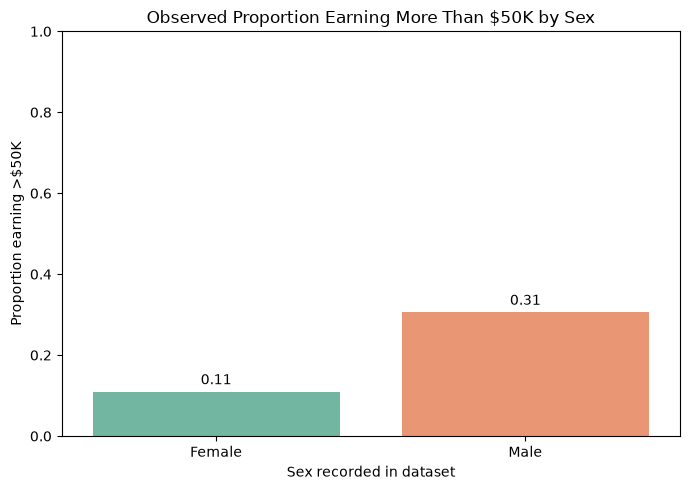

In [29]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=sex_summary,
    x="sex",
    y="proportion_above_50k",
    hue="sex",
    palette="Set2",
    legend=False
)

plt.title("Observed Proportion Earning More Than $50K by Sex")
plt.xlabel("Sex recorded in dataset")
plt.ylabel("Proportion earning >$50K")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [30]:
race_summary = (
    df.groupby("race", observed=True)
    .agg(
        number_of_people=("income_binary", "size"),
        number_above_50k=("income_binary", "sum"),
        proportion_above_50k=("income_binary", "mean")
    )
    .reset_index()
    .sort_values("proportion_above_50k", ascending=False)
)

race_summary

,race,number_of_people,number_above_50k,proportion_above_50k
1,Asian-Pac-Islander,1038,276,0.265896
4,White,27795,7115,0.255981
2,Black,3122,387,0.123959
0,Amer-Indian-Eskimo,311,36,0.115756
3,Other,271,25,0.092251


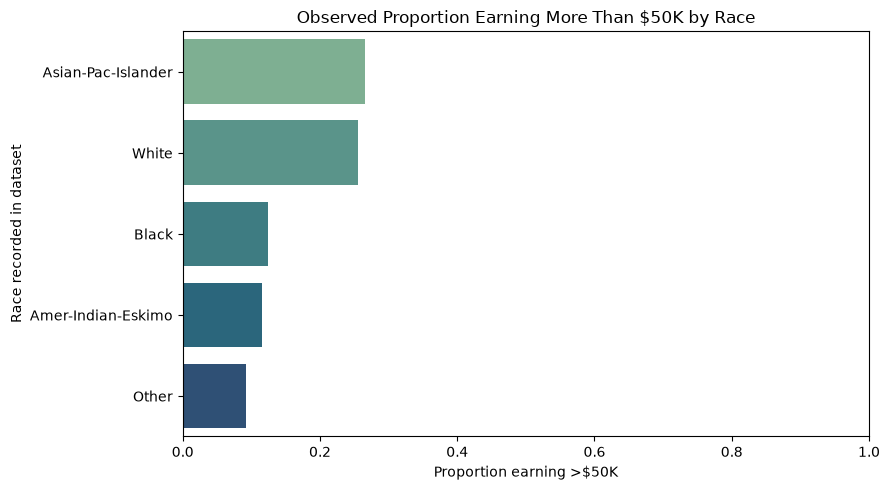

In [31]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=race_summary,
    x="proportion_above_50k",
    y="race",
    hue="race",
    palette="crest",
    legend=False
)

plt.title("Observed Proportion Earning More Than $50K by Race")
plt.xlabel("Proportion earning >$50K")
plt.ylabel("Race recorded in dataset")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [32]:
sex_rates = sex_summary.set_index("sex")["proportion_above_50k"]

observed_sex_gap = sex_rates["Male"] - sex_rates["Female"]

print(f"Observed difference in >$50K proportions: {observed_sex_gap:.3f}")

Observed difference in >$50K proportions: 0.196


### Protected-characteristic analysis

Income proportions differed across sex and race categories in the dataset.
These are unadjusted descriptive associations and may reflect historical
inequalities, differences in measured socioeconomic characteristics,
unmeasured confounding, sampling limitations, and structural discrimination.

Race and sex are protected, non-actionable characteristics. They may be
examined to assess disparities and model fairness, but they will never be
presented as characteristics that a user should change.

Furthermore, unequal model predictions should not be interpreted as evidence
that a protected characteristic inherently determines earning potential.
The model learns patterns from historical data and may reproduce historical
biases present in those data.

## Recommendation-system definition

The "user" is an adult represented by a socioeconomic profile containing
demographic, educational, occupational, and financial characteristics.

The classification model estimates the probability that the user's annual
income belongs to the `>50K` category.

The recommendation component uses a content-based, counterfactual approach.
It creates alternative versions of the user's profile by modifying selected
potentially actionable variables and recalculating the predicted probability.

Variables eligible for hypothetical modification include:

- Education
- Occupation
- Work class
- Hours worked per week

Protected or non-actionable characteristics—including race, sex, age,
country of origin, marital status, and relationship status—are held constant
and are never recommended as changes.

The system ranks hypothetical alternatives according to the increase in the
model-estimated probability of earning more than $50,000. These results
represent associations learned from historical data and are not causal
guarantees or individualized financial advice.

In [33]:
model_features = [
    "age",
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country"
]

X = df[model_features].copy()
y = df["income_binary"].copy()

In [34]:
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (32537, 12)
y shape: (32537,)


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,90,NaN,HS-grad,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,HS-grad,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,NaN,Some-college,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,7th-8th,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,Some-college,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


0    0
1    0
2    0
3    0
4    0
Name: income_binary, dtype: int64

In [35]:
numerical_features = [
    "age",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

In [36]:
set(model_features) == set(numerical_features + categorical_features)

True

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26029, 12)
X_test shape: (6508, 12)
y_train shape: (26029,)
y_test shape: (6508,)


In [39]:
print("Training outcome proportions:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting outcome proportions:")
print(y_test.value_counts(normalize=True).round(4))

Training outcome proportions:
income_binary
0    0.7591
1    0.2409
Name: proportion, dtype: float64

Testing outcome proportions:
income_binary
0    0.7591
1    0.2409
Name: proportion, dtype: float64


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [41]:
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [42]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="Unknown"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [43]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    verbose_feature_names_out=False
)

In [44]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [45]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (26029, 12)
Processed training shape: (26029, 105)
Original testing shape: (6508, 12)
Processed testing shape: (6508, 105)


In [46]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))
print(processed_feature_names)

Number of processed features: 105
['age' 'capital_gain' 'capital_loss' 'hours_per_week'
 'workclass_Federal-gov' 'workclass_Local-gov' 'workclass_Never-worked'
 'workclass_Private' 'workclass_Self-emp-inc' 'workclass_Self-emp-not-inc'
 'workclass_State-gov' 'workclass_Unknown' 'workclass_Without-pay'
 'education_10th' 'education_11th' 'education_12th' 'education_1st-4th'
 'education_5th-6th' 'education_7th-8th' 'education_9th'
 'education_Assoc-acdm' 'education_Assoc-voc' 'education_Bachelors'
 'education_Doctorate' 'education_HS-grad' 'education_Masters'
 'education_Preschool' 'education_Prof-school' 'education_Some-college'
 'marital_status_Divorced' 'marital_status_Married-AF-spouse'
 'marital_status_Married-civ-spouse'
 'marital_status_Married-spouse-absent' 'marital_status_Never-married'
 'marital_status_Separated' 'marital_status_Widowed'
 'occupation_Adm-clerical' 'occupation_Armed-Forces'
 'occupation_Craft-repair' 'occupation_Exec-managerial'
 'occupation_Farming-fishing' 'occ

In [47]:
example_profile = X_train.iloc[[0]]

display(example_profile)

,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
25252,21,NaN,Some-college,Never-married,NaN,Own-child,White,Male,0,0,20,United-States


In [48]:
example_processed = preprocessor.transform(example_profile)

if hasattr(example_processed, "toarray"):
    example_processed = example_processed.toarray()

example_processed_df = pd.DataFrame(
    example_processed,
    columns=processed_feature_names
)

display(example_processed_df)

,age,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Unknown,workclass_Without-pay,education_10th,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital_status_Divorced,marital_status_Married-AF-spouse,marital_status_Married-civ-spouse,marital_status_Married-spouse-absent,marital_status_Never-married,marital_status_Separated,marital_status_Widowed,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,native_country_Cambodia,native_country_Canada,native_country_China,native_country_Columbia,native_country_Cuba,native_country_Dominican-Republic,native_country_Ecuador,native_country_El-Salvador,native_country_England,native_country_France,native_country_Germany,native_country_Greece,native_country_Guatemala,native_country_Haiti,native_country_Honduras,native_country_Hong,native_country_Hungary,native_country_India,native_country_Iran,native_country_Ireland,native_country_Italy,native_country_Jamaica,native_country_Japan,native_country_Laos,native_country_Mexico,native_country_Nicaragua,native_country_Outlying-US(Guam-USVI-etc),native_country_Peru,native_country_Philippines,native_country_Poland,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Unknown,native_country_Vietnam,native_country_Yugoslavia
0,-1.285119,-0.146741,-0.21798,-1.66347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [49]:
active_features = example_processed_df.loc[
    0,
    example_processed_df.loc[0] != 0
].sort_values()

active_features

hours_per_week                 -1.663470
age                            -1.285119
capital_loss                   -0.217980
capital_gain                   -0.146741
workclass_Unknown               1.000000
education_Some-college          1.000000
marital_status_Never-married    1.000000
occupation_Unknown              1.000000
relationship_Own-child          1.000000
race_White                      1.000000
sex_Male                        1.000000
native_country_United-States    1.000000
Name: 0, dtype: float64

In [50]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

In [51]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','workclass','education',...,'capital_loss','hours_per_week', 'native_country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that featur

In [52]:
y_train_pred = logistic_model.predict(X_train)
y_test_pred = logistic_model.predict(X_test)

y_train_probability = logistic_model.predict_proba(X_train)[:, 1]
y_test_probability = logistic_model.predict_proba(X_test)[:, 1]

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "Balanced_accuracy": [
        balanced_accuracy_score(y_train, y_train_pred),
        balanced_accuracy_score(y_test, y_test_pred)
    ],
    "Precision": [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    "Recall": [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],
    "F1": [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_train, y_train_probability),
        roc_auc_score(y_test, y_test_probability)
    ],
    "PR_AUC": [
        average_precision_score(y_train, y_train_probability),
        average_precision_score(y_test, y_test_probability)
    ]
})

results.round(4)

,Dataset,Accuracy,Balanced_accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Training,0.8528,0.7680,0.7374,0.6044,0.6643,0.9098,0.7714
1,Testing,0.8506,0.7643,0.7332,0.5976,0.6585,0.9018,0.7646


In [54]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["<=50K", ">50K"]
    )
)

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4940
        >50K       0.73      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.76      0.78      6508
weighted avg       0.84      0.85      0.85      6508



In [55]:
test_confusion_matrix = confusion_matrix(y_test, y_test_pred)

print(test_confusion_matrix)

[[4599  341]
 [ 631  937]]


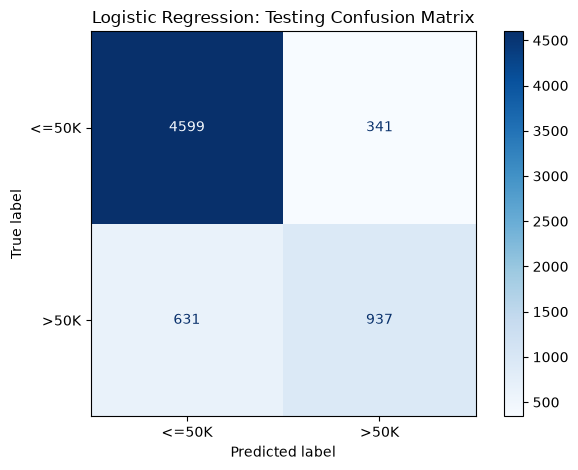

In [56]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression: Testing Confusion Matrix")
plt.tight_layout()
plt.show()

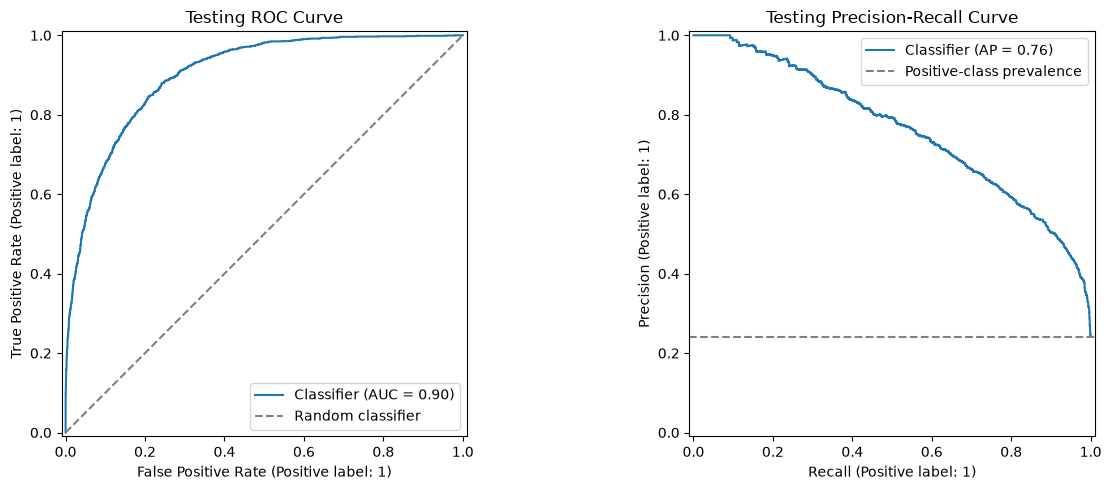

In [57]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test,
    y_test_probability,
    ax=axes[0]
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)

axes[0].set_title("Testing ROC Curve")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_probability,
    ax=axes[1]
)

axes[1].axhline(
    y=y_test.mean(),
    linestyle="--",
    color="gray",
    label="Positive-class prevalence"
)

axes[1].set_title("Testing Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

### Baseline logistic-regression performance

The logistic-regression pipeline achieved a testing accuracy of 85.1%,
compared with a majority-class baseline of 75.9%. Training and testing
performance were closely aligned, suggesting little evidence of overfitting.

Testing ROC-AUC was 0.902, indicating excellent ability to rank observations
from the two income categories. PR-AUC was 0.765, substantially greater than
the positive-class prevalence of approximately 0.241.

For the `>50K` class, precision was 0.733 and recall was 0.598. Therefore,
predictions above $50,000 were usually correct, but the default classification
threshold failed to identify approximately 40% of observations actually in
that class.

Because the eventual recommendation system relies primarily on changes in
predicted probability rather than only the final binary classification,
ranking performance is particularly relevant.

## Permutation importance

In [59]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    logistic_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [60]:
permutation_summary = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
}).sort_values("importance_mean", ascending=False)

permutation_summary.round(4)

,feature,importance_mean,importance_std
3,marital_status,0.0852,0.0031
2,education,0.0354,0.0013
8,capital_gain,0.0334,0.0019
4,occupation,0.0203,0.0016
5,relationship,0.0147,0.0010
10,hours_per_week,0.0096,0.0008
7,sex,0.0086,0.0011
0,age,0.0077,0.0011
9,capital_loss,0.0046,0.0009
1,workclass,0.0026,0.0005


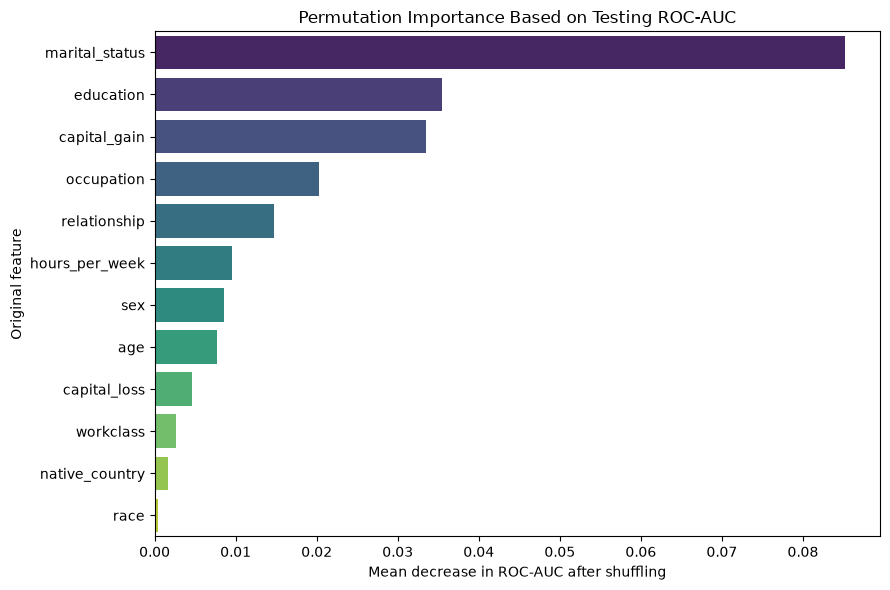

In [61]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=permutation_summary,
    x="importance_mean",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Permutation Importance Based on Testing ROC-AUC")
plt.xlabel("Mean decrease in ROC-AUC after shuffling")
plt.ylabel("Original feature")

plt.tight_layout()
plt.show()

## Extract logistic-regression coefficients

In [62]:
fitted_preprocessor = logistic_model.named_steps["preprocessor"]
fitted_classifier = logistic_model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_classifier.coef_[0]

coefficient_summary = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coefficient_summary["absolute_coefficient"] = (
    coefficient_summary["coefficient"].abs()
)

In [63]:
top_positive = (
    coefficient_summary
    .sort_values("coefficient", ascending=False)
    .head(15)
)

top_positive[["feature", "coefficient"]].round(3)

,feature,coefficient
1,capital_gain,2.317
23,education_Doctorate,1.936
27,education_Prof-school,1.805
25,education_Masters,1.304
30,marital_status_Married-AF-spouse,1.210
56,relationship_Wife,1.160
31,marital_status_Married-civ-spouse,1.150
22,education_Bachelors,0.992
64,native_country_Cambodia,0.990
84,native_country_Italy,0.936


In [64]:
top_negative = (
    coefficient_summary
    .sort_values("coefficient", ascending=True)
    .head(15)
)

top_negative[["feature", "coefficient"]].round(3)

,feature,coefficient
26,education_Preschool,-1.479
44,occupation_Priv-house-serv,-1.467
18,education_7th-8th,-1.466
54,relationship_Own-child,-1.263
17,education_5th-6th,-1.162
67,native_country_Columbia,-1.135
33,marital_status_Never-married,-1.113
19,education_9th,-1.000
40,occupation_Farming-fishing,-0.988
62,sex_Female,-0.984


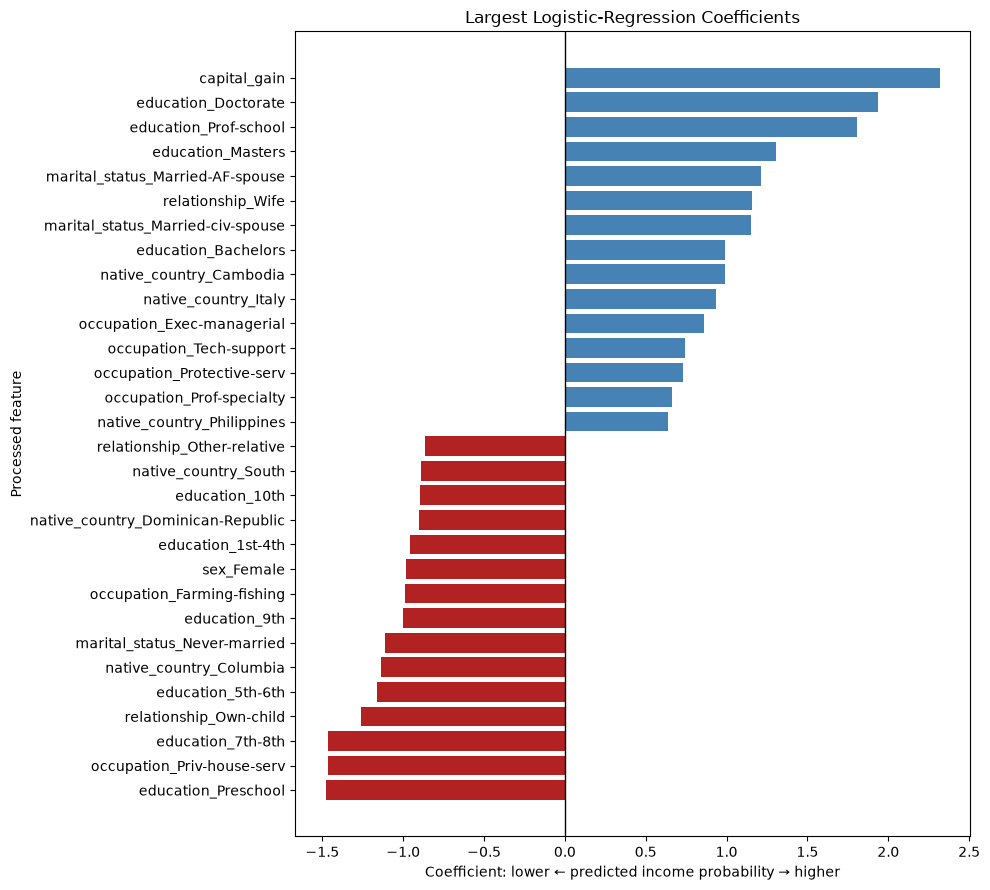

In [67]:
coefficient_plot = pd.concat([
    top_negative,
    top_positive
]).sort_values("coefficient")

plt.figure(figsize=(10, 9))

colors = [
    "firebrick" if value < 0 else "steelblue"
    for value in coefficient_plot["coefficient"]
]

plt.barh(
    coefficient_plot["feature"],
    coefficient_plot["coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Largest Logistic-Regression Coefficients")
plt.xlabel("Coefficient: lower ← predicted income probability → higher")
plt.ylabel("Processed feature")

plt.tight_layout()
plt.show()

### Model interpretation

Permutation importance indicated that marital status contributed most strongly
to the model's ranking performance, followed by education, capital gain,
occupation, relationship status, and weekly working hours.

Higher educational categories and executive, professional, technical, and
protective-service occupations received positive logistic-regression
coefficients. Several lower educational categories and service occupations
received negative coefficients.

Protected and non-actionable variables may be predictive but are not
appropriate recommendations. In particular, sex was associated with model
predictions, while race provided little additional predictive information
after accounting for the remaining variables.

Coefficient magnitude and permutation importance answer different questions.
Coefficients describe the direction and weight assigned to individual encoded
features, whereas permutation importance measures how much overall model
performance deteriorates when an original variable's information is disrupted.

All interpretations describe patterns learned from historical data and should
not be considered causal effects.

# Build recommendation system

In [68]:
user_profile = {
    "age": 25,
    "workclass": "Private",
    "education": "HS-grad",
    "marital_status": "Never-married",
    "occupation": "Other-service",
    "relationship": "Not-in-family",
    "race": "White",
    "sex": "Male",
    "capital_gain": 0,
    "capital_loss": 0,
    "hours_per_week": 20,
    "native_country": "United-States"
}

In [69]:
def predict_income_probability(profile, model=logistic_model):
    """
    Estimate the probability of annual income above $50K
    for one socioeconomic profile.
    """
    
    profile_df = pd.DataFrame(
        [profile],
        columns=model_features
    )
    
    probability = model.predict_proba(profile_df)[0, 1]
    predicted_class = model.predict(profile_df)[0]
    
    return {
        "probability_above_50k": probability,
        "predicted_class": ">50K" if predicted_class == 1 else "<=50K"
    }

In [70]:
baseline_prediction = predict_income_probability(user_profile)

baseline_prediction

{'probability_above_50k': np.float64(0.005672068103068138),
 'predicted_class': '<=50K'}

In [71]:
education_options = [
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

occupation_options = [
    "Adm-clerical",
    "Craft-repair",
    "Sales",
    "Tech-support",
    "Protective-serv",
    "Prof-specialty",
    "Exec-managerial"
]

workclass_options = [
    "Private",
    "Self-emp-not-inc",
    "Self-emp-inc",
    "Local-gov",
    "State-gov",
    "Federal-gov"
]

hours_options = [
    30,
    35,
    40,
    45,
    50
]

In [72]:
baseline_probability = baseline_prediction["probability_above_50k"]

candidate_recommendations = []

In [73]:
for education in education_options:
    candidate = user_profile.copy()
    candidate["education"] = education
    
    prediction = predict_income_probability(candidate)
    
    candidate_recommendations.append({
        "variable_changed": "education",
        "original_value": user_profile["education"],
        "suggested_value": education,
        "predicted_probability": prediction["probability_above_50k"],
        "predicted_class": prediction["predicted_class"]
    })

In [74]:
for occupation in occupation_options:
    candidate = user_profile.copy()
    candidate["occupation"] = occupation
    
    prediction = predict_income_probability(candidate)
    
    candidate_recommendations.append({
        "variable_changed": "occupation",
        "original_value": user_profile["occupation"],
        "suggested_value": occupation,
        "predicted_probability": prediction["probability_above_50k"],
        "predicted_class": prediction["predicted_class"]
    })

In [75]:
for workclass in workclass_options:
    if workclass == user_profile["workclass"]:
        continue
    
    candidate = user_profile.copy()
    candidate["workclass"] = workclass
    
    prediction = predict_income_probability(candidate)
    
    candidate_recommendations.append({
        "variable_changed": "workclass",
        "original_value": user_profile["workclass"],
        "suggested_value": workclass,
        "predicted_probability": prediction["probability_above_50k"],
        "predicted_class": prediction["predicted_class"]
    })

In [76]:
for hours in hours_options:
    candidate = user_profile.copy()
    candidate["hours_per_week"] = hours
    
    prediction = predict_income_probability(candidate)
    
    candidate_recommendations.append({
        "variable_changed": "hours_per_week",
        "original_value": user_profile["hours_per_week"],
        "suggested_value": hours,
        "predicted_probability": prediction["probability_above_50k"],
        "predicted_class": prediction["predicted_class"]
    })

In [77]:
recommendation_results = pd.DataFrame(candidate_recommendations)

recommendation_results["probability_change"] = (
    recommendation_results["predicted_probability"]
    - baseline_probability
)

recommendation_results["percentage_point_change"] = (
    recommendation_results["probability_change"] * 100
)

recommendation_results = recommendation_results.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

print(f"Baseline probability above $50K: {baseline_probability:.2%}")
print(f"Baseline predicted class: {baseline_prediction['predicted_class']}")

display(
    recommendation_results[
        [
            "variable_changed",
            "original_value",
            "suggested_value",
            "predicted_probability",
            "percentage_point_change",
            "predicted_class"
        ]
    ].round({
        "predicted_probability": 4,
        "percentage_point_change": 2
    })
)

Baseline probability above $50K: 0.57%
Baseline predicted class: <=50K


,variable_changed,original_value,suggested_value,predicted_probability,percentage_point_change,predicted_class
0,education,HS-grad,Doctorate,0.0420,3.63,<=50K
1,education,HS-grad,Prof-school,0.0370,3.14,<=50K
2,occupation,Other-service,Exec-managerial,0.0300,2.44,<=50K
3,occupation,Other-service,Tech-support,0.0267,2.10,<=50K
4,occupation,Other-service,Protective-serv,0.0265,2.08,<=50K
5,occupation,Other-service,Prof-specialty,0.0248,1.91,<=50K
6,education,HS-grad,Masters,0.0228,1.71,<=50K
7,occupation,Other-service,Sales,0.0184,1.27,<=50K
8,education,HS-grad,Bachelors,0.0168,1.11,<=50K
9,occupation,Other-service,Craft-repair,0.0148,0.91,<=50K


## Build combined socioeconomic trajectories

In [78]:
trajectory_definitions = {
    "Current profile": {},
    
    "Full-time service work": {
        "hours_per_week": 40
    },
    
    "Technical certificate pathway": {
        "education": "Assoc-voc",
        "occupation": "Tech-support",
        "hours_per_week": 40
    },
    
    "Technical college pathway": {
        "education": "Assoc-acdm",
        "occupation": "Tech-support",
        "hours_per_week": 40
    },
    
    "Bachelor's professional pathway": {
        "education": "Bachelors",
        "occupation": "Prof-specialty",
        "hours_per_week": 40
    },
    
    "Bachelor's managerial pathway": {
        "education": "Bachelors",
        "occupation": "Exec-managerial",
        "hours_per_week": 45
    },
    
    "Master's professional pathway": {
        "education": "Masters",
        "occupation": "Prof-specialty",
        "hours_per_week": 40
    },
    
    "Professional-school pathway": {
        "education": "Prof-school",
        "occupation": "Prof-specialty",
        "hours_per_week": 45
    },
    
    "Doctoral professional pathway": {
        "education": "Doctorate",
        "occupation": "Prof-specialty",
        "hours_per_week": 45
    }
}

In [79]:
trajectory_results = []

for trajectory_name, changes in trajectory_definitions.items():
    candidate_profile = user_profile.copy()
    candidate_profile.update(changes)
    
    prediction = predict_income_probability(candidate_profile)
    
    changed_features = ", ".join(
        f"{feature}: {user_profile[feature]} → {new_value}"
        for feature, new_value in changes.items()
    )
    
    if not changed_features:
        changed_features = "No changes"
    
    trajectory_results.append({
        "trajectory": trajectory_name,
        "changes": changed_features,
        "predicted_probability": prediction["probability_above_50k"],
        "predicted_class": prediction["predicted_class"]
    })

In [80]:
trajectory_results = pd.DataFrame(trajectory_results)

trajectory_results["probability_change"] = (
    trajectory_results["predicted_probability"]
    - baseline_probability
)

trajectory_results["percentage_point_change"] = (
    trajectory_results["probability_change"] * 100
)

trajectory_results = trajectory_results.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

display(
    trajectory_results[
        [
            "trajectory",
            "changes",
            "predicted_probability",
            "percentage_point_change",
            "predicted_class"
        ]
    ].round({
        "predicted_probability": 4,
        "percentage_point_change": 2
    })
)

,trajectory,changes,predicted_probability,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: HS-grad → Doctorate, occupation: Ot...",0.2895,28.39,<=50K
1,Professional-school pathway,"education: HS-grad → Prof-school, occupation: ...",0.2633,25.76,<=50K
2,Bachelor's managerial pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.1619,15.62,<=50K
3,Master's professional pathway,"education: HS-grad → Masters, occupation: Othe...",0.1575,15.18,<=50K
4,Bachelor's professional pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.1203,11.47,<=50K
5,Technical certificate pathway,"education: HS-grad → Assoc-voc, occupation: Ot...",0.0763,7.06,<=50K
6,Technical college pathway,"education: HS-grad → Assoc-acdm, occupation: O...",0.0742,6.85,<=50K
7,Full-time service work,hours_per_week: 20 → 40,0.0102,0.45,<=50K
8,Current profile,No changes,0.0057,0.00,<=50K


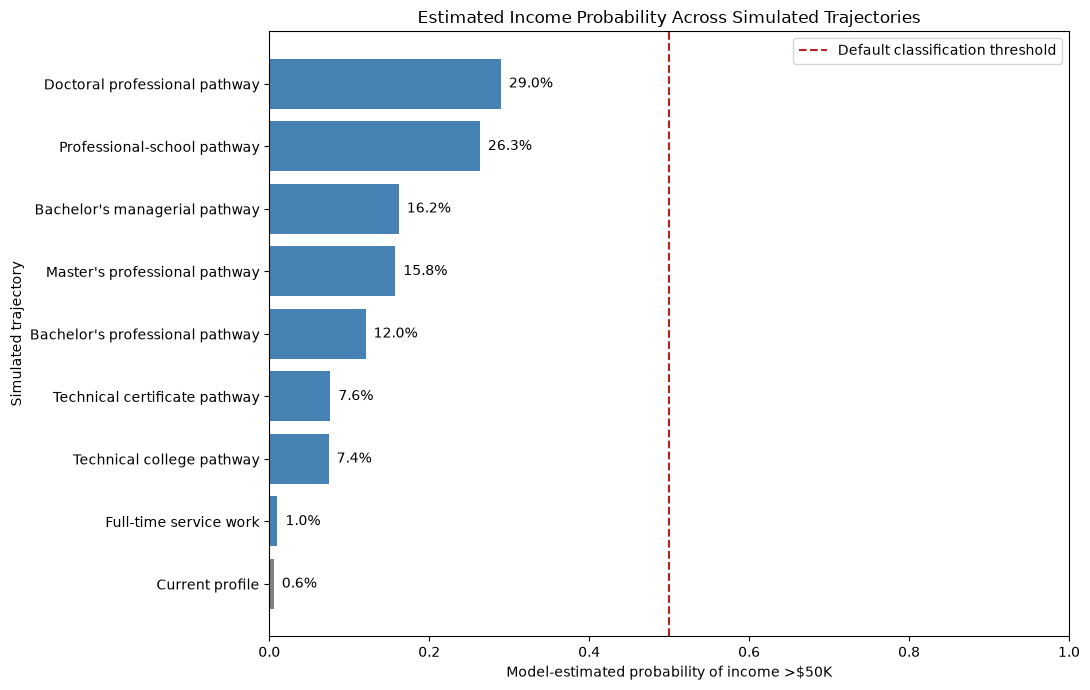

In [81]:
plt.figure(figsize=(11, 7))

plot_data = trajectory_results.sort_values(
    "predicted_probability",
    ascending=True
)

colors = [
    "gray" if trajectory == "Current profile" else "steelblue"
    for trajectory in plot_data["trajectory"]
]

bars = plt.barh(
    plot_data["trajectory"],
    plot_data["predicted_probability"],
    color=colors
)

plt.axvline(
    0.50,
    color="firebrick",
    linestyle="--",
    label="Default classification threshold"
)

plt.xlabel("Model-estimated probability of income >$50K")
plt.ylabel("Simulated trajectory")
plt.title("Estimated Income Probability Across Simulated Trajectories")
plt.xlim(0, 1)

for bar, probability in zip(
    bars,
    plot_data["predicted_probability"]
):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{probability:.1%}",
        va="center"
    )

plt.legend()
plt.tight_layout()
plt.show()

### Initial simulated profile

The initial profile received a low estimated probability of income above
$50,000. Modifying only one variable improved the estimated probability but
did not change the final predicted class.

Education and occupation changes produced larger probability increases than
changes in work class or weekly working hours. Combined trajectories produced
larger changes because they represented coordinated modifications of multiple
socioeconomic characteristics.

These trajectories should be interpreted as model-based scenarios rather
than causal or prescriptive recommendations. The underlying dataset does not
contain longitudinal evidence showing that individuals who made these changes
subsequently experienced the predicted income improvement.

## Find similar successful profiles

In [82]:
fitted_preprocessor = logistic_model.named_steps["preprocessor"]

X_train_similarity = fitted_preprocessor.transform(X_train)

successful_mask = y_train == 1

successful_profiles = X_train.loc[successful_mask].copy()
successful_matrix = X_train_similarity[successful_mask.to_numpy()]

print("Successful training profiles:", successful_profiles.shape)
print("Successful transformed matrix:", successful_matrix.shape)

Successful training profiles: (6271, 12)
Successful transformed matrix: (6271, 105)


In [83]:
from sklearn.neighbors import NearestNeighbors

neighbor_model = NearestNeighbors(
    n_neighbors=25,
    metric="cosine",
    algorithm="brute"
)

neighbor_model.fit(successful_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [84]:
user_df = pd.DataFrame(
    [user_profile],
    columns=model_features
)

user_vector = fitted_preprocessor.transform(user_df)

distances, indices = neighbor_model.kneighbors(user_vector)

nearest_successful_profiles = successful_profiles.iloc[
    indices[0]
].copy()

nearest_successful_profiles["similarity_score"] = (
    1 - distances[0]
)

nearest_successful_profiles = nearest_successful_profiles.sort_values(
    "similarity_score",
    ascending=False
)

display(
    nearest_successful_profiles[
        [
            "age",
            "education",
            "occupation",
            "workclass",
            "hours_per_week",
            "marital_status",
            "relationship",
            "similarity_score"
        ]
    ].head(10)
)

,age,education,occupation,workclass,hours_per_week,marital_status,relationship,similarity_score
24499,22,Some-college,Other-service,Private,32,Never-married,Own-child,0.773494
26863,33,HS-grad,Craft-repair,Private,40,Never-married,Not-in-family,0.763229
24021,38,HS-grad,Prof-specialty,Private,40,Never-married,Not-in-family,0.733584
3203,35,HS-grad,Sales,Private,40,Never-married,Not-in-family,0.733355
20642,32,HS-grad,Transport-moving,Private,20,Married-civ-spouse,Husband,0.726654
7251,35,HS-grad,Other-service,Private,16,Married-civ-spouse,Wife,0.722135
8704,25,HS-grad,Sales,Private,26,Married-civ-spouse,Own-child,0.721047
2261,29,HS-grad,Other-service,Private,40,Divorced,Not-in-family,0.695846
2360,35,HS-grad,Adm-clerical,Private,40,Never-married,Not-in-family,0.694526
17907,25,Bachelors,Adm-clerical,Private,40,Never-married,Not-in-family,0.687481


In [85]:
neighbor_education_summary = (
    nearest_successful_profiles["education"]
    .value_counts()
    .rename_axis("education")
    .reset_index(name="neighbor_count")
)

neighbor_education_summary

,education,neighbor_count
0,HS-grad,10
1,Bachelors,7
2,Some-college,4
3,Doctorate,2
4,Prof-school,1
5,Masters,1


In [86]:
neighbor_occupation_summary = (
    nearest_successful_profiles["occupation"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("occupation")
    .reset_index(name="neighbor_count")
)

neighbor_occupation_summary

,occupation,neighbor_count
0,Other-service,8
1,Prof-specialty,6
2,Sales,4
3,Craft-repair,2
4,Transport-moving,2
5,Adm-clerical,2
6,Exec-managerial,1


In [87]:
neighbor_workclass_summary = (
    nearest_successful_profiles["workclass"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("workclass")
    .reset_index(name="neighbor_count")
)

neighbor_workclass_summary

,workclass,neighbor_count
0,Private,25


In [88]:
nearest_successful_profiles["hours_per_week"].describe()

count    25.000000
mean     34.680000
std       8.091765
min      16.000000
25%      30.000000
50%      40.000000
75%      40.000000
max      41.000000
Name: hours_per_week, dtype: float64

In [89]:
display(
    nearest_successful_profiles[
        [
            "age",
            "education",
            "occupation",
            "workclass",
            "hours_per_week",
            "capital_gain",
            "capital_loss",
            "marital_status",
            "relationship",
            "similarity_score"
        ]
    ].head(25)
)

,age,education,occupation,workclass,hours_per_week,capital_gain,capital_loss,marital_status,relationship,similarity_score
24499,22,Some-college,Other-service,Private,32,0,0,Never-married,Own-child,0.773494
26863,33,HS-grad,Craft-repair,Private,40,0,0,Never-married,Not-in-family,0.763229
24021,38,HS-grad,Prof-specialty,Private,40,0,0,Never-married,Not-in-family,0.733584
3203,35,HS-grad,Sales,Private,40,4787,0,Never-married,Not-in-family,0.733355
20642,32,HS-grad,Transport-moving,Private,20,0,0,Married-civ-spouse,Husband,0.726654
7251,35,HS-grad,Other-service,Private,16,0,0,Married-civ-spouse,Wife,0.722135
8704,25,HS-grad,Sales,Private,26,0,0,Married-civ-spouse,Own-child,0.721047
2261,29,HS-grad,Other-service,Private,40,10520,0,Divorced,Not-in-family,0.695846
2360,35,HS-grad,Adm-clerical,Private,40,8614,0,Never-married,Not-in-family,0.694526
17907,25,Bachelors,Adm-clerical,Private,40,0,0,Never-married,Not-in-family,0.687481


In [90]:
neighbor_financial_audit = pd.Series({
    "neighbors_with_capital_gain": (
        nearest_successful_profiles["capital_gain"] > 0
    ).sum(),
    
    "neighbors_with_capital_loss": (
        nearest_successful_profiles["capital_loss"] > 0
    ).sum(),
    
    "neighbors_with_either": (
        (nearest_successful_profiles["capital_gain"] > 0)
        |
        (nearest_successful_profiles["capital_loss"] > 0)
    ).sum()
})

neighbor_financial_audit

neighbors_with_capital_gain    3
neighbors_with_capital_loss    0
neighbors_with_either          3
dtype: int64

In [91]:
career_success_mask = (
    (y_train == 1)
    & (X_train["capital_gain"] == 0)
    & (X_train["capital_loss"] == 0)
)

career_successful_profiles = X_train.loc[
    career_success_mask
].copy()

career_successful_matrix = X_train_similarity[
    career_success_mask.to_numpy()
]

print(
    "Career-focused successful profiles:",
    career_successful_profiles.shape
)

Career-focused successful profiles: (4285, 12)


In [92]:
career_neighbor_model = NearestNeighbors(
    n_neighbors=25,
    metric="cosine",
    algorithm="brute"
)

career_neighbor_model.fit(career_successful_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [93]:
career_distances, career_indices = (
    career_neighbor_model.kneighbors(user_vector)
)

career_neighbors = career_successful_profiles.iloc[
    career_indices[0]
].copy()

career_neighbors["similarity_score"] = (
    1 - career_distances[0]
)

career_neighbors = career_neighbors.sort_values(
    "similarity_score",
    ascending=False
)

In [94]:
display(
    career_neighbors[
        [
            "age",
            "education",
            "occupation",
            "workclass",
            "hours_per_week",
            "marital_status",
            "relationship",
            "similarity_score"
        ]
    ].head(10)
)

,age,education,occupation,workclass,hours_per_week,marital_status,relationship,similarity_score
24499,22,Some-college,Other-service,Private,32,Never-married,Own-child,0.773494
26863,33,HS-grad,Craft-repair,Private,40,Never-married,Not-in-family,0.763229
24021,38,HS-grad,Prof-specialty,Private,40,Never-married,Not-in-family,0.733584
20642,32,HS-grad,Transport-moving,Private,20,Married-civ-spouse,Husband,0.726654
7251,35,HS-grad,Other-service,Private,16,Married-civ-spouse,Wife,0.722135
8704,25,HS-grad,Sales,Private,26,Married-civ-spouse,Own-child,0.721047
17907,25,Bachelors,Adm-clerical,Private,40,Never-married,Not-in-family,0.687481
19731,36,HS-grad,Transport-moving,Private,25,Married-civ-spouse,Husband,0.686304
5276,44,Bachelors,Other-service,Private,40,Never-married,Not-in-family,0.682081
26475,30,Bachelors,Sales,Private,40,Never-married,Not-in-family,0.674775


In [95]:
career_education_summary = (
    career_neighbors["education"]
    .value_counts()
    .rename_axis("education")
    .reset_index(name="neighbor_count")
)

career_occupation_summary = (
    career_neighbors["occupation"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("occupation")
    .reset_index(name="neighbor_count")
)

career_workclass_summary = (
    career_neighbors["workclass"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("workclass")
    .reset_index(name="neighbor_count")
)

career_hours_summary = (
    career_neighbors["hours_per_week"]
    .describe()
)

display(career_education_summary)
display(career_occupation_summary)
display(career_workclass_summary)
display(career_hours_summary)

,education,neighbor_count
0,HS-grad,8
1,Bachelors,7
2,Some-college,5
3,Doctorate,2
4,Prof-school,2
5,Masters,1


,occupation,neighbor_count
0,Other-service,7
1,Prof-specialty,7
2,Sales,3
3,Craft-repair,2
4,Transport-moving,2
5,Exec-managerial,2
6,Adm-clerical,1
7,Tech-support,1


,workclass,neighbor_count
0,Private,25


count    25.000000
mean     34.480000
std       8.016234
min      16.000000
25%      30.000000
50%      40.000000
75%      40.000000
max      41.000000
Name: hours_per_week, dtype: float64

In [96]:
education_rank = {
    "Preschool": 1,
    "1st-4th": 2,
    "5th-6th": 3,
    "7th-8th": 4,
    "9th": 5,
    "10th": 6,
    "11th": 7,
    "12th": 8,
    "HS-grad": 9,
    "Some-college": 10,
    "Assoc-voc": 11,
    "Assoc-acdm": 12,
    "Bachelors": 13,
    "Masters": 14,
    "Prof-school": 15,
    "Doctorate": 16
}

In [97]:
def hybrid_income_recommender(
    profile,
    trajectory_library,
    model=logistic_model,
    preprocessor=fitted_preprocessor,
    neighbor_model=career_neighbor_model,
    neighbor_profiles=career_successful_profiles,
    k=25,
    top_n=5
):
    """
    Combine counterfactual probability scoring with content-based
    retrieval of similar higher-income profiles.
    """
    
    # Confirm that every required model variable is present
    missing_features = [
        feature
        for feature in model_features
        if feature not in profile
    ]
    
    if missing_features:
        raise ValueError(
            f"Profile is missing required features: {missing_features}"
        )
    
    # Calculate baseline prediction
    baseline = predict_income_probability(profile, model=model)
    baseline_probability = baseline["probability_above_50k"]
    
    # Score candidate trajectories
    trajectory_rows = []
    
    for trajectory_name, changes in trajectory_library.items():
        
        # We add the current profile separately
        if trajectory_name == "Current profile":
            continue
        
        # Do not recommend a lower education category
        if "education" in changes:
            current_rank = education_rank.get(profile["education"], 0)
            proposed_rank = education_rank.get(changes["education"], 0)
            
            if proposed_rank < current_rank:
                continue
        
        candidate = profile.copy()
        candidate.update(changes)
        
        prediction = predict_income_probability(
            candidate,
            model=model
        )
        
        changed_features = ", ".join(
            f"{feature}: {profile[feature]} → {new_value}"
            for feature, new_value in changes.items()
            if profile[feature] != new_value
        )
        
        if not changed_features:
            continue
        
        trajectory_rows.append({
            "trajectory": trajectory_name,
            "changes": changed_features,
            "predicted_probability": (
                prediction["probability_above_50k"]
            ),
            "probability_change": (
                prediction["probability_above_50k"]
                - baseline_probability
            ),
            "percentage_point_change": (
                prediction["probability_above_50k"]
                - baseline_probability
            ) * 100,
            "predicted_class": prediction["predicted_class"]
        })
    
    trajectory_table = pd.DataFrame(trajectory_rows)
    
    # Retain only scenarios that improve the model estimate
    if not trajectory_table.empty:
        trajectory_table = (
            trajectory_table[
                trajectory_table["probability_change"] > 0
            ]
            .sort_values(
                "predicted_probability",
                ascending=False
            )
            .head(top_n)
            .reset_index(drop=True)
        )
    
    # Content-based neighbor retrieval
    profile_df = pd.DataFrame(
        [profile],
        columns=model_features
    )
    
    profile_vector = preprocessor.transform(profile_df)
    
    distances, indices = neighbor_model.kneighbors(
        profile_vector,
        n_neighbors=k
    )
    
    neighbors = neighbor_profiles.iloc[
        indices[0]
    ].copy()
    
    neighbors["similarity_score"] = 1 - distances[0]
    
    # Summaries of actionable characteristics
    peer_education = (
        neighbors["education"]
        .value_counts()
        .head(5)
        .rename_axis("education")
        .reset_index(name="neighbor_count")
    )
    
    peer_occupation = (
        neighbors["occupation"]
        .fillna("Unknown")
        .value_counts()
        .head(5)
        .rename_axis("occupation")
        .reset_index(name="neighbor_count")
    )
    
    peer_workclass = (
        neighbors["workclass"]
        .fillna("Unknown")
        .value_counts()
        .head(5)
        .rename_axis("workclass")
        .reset_index(name="neighbor_count")
    )
    
    peer_hours = {
        "median": neighbors["hours_per_week"].median(),
        "lower_quartile": neighbors["hours_per_week"].quantile(0.25),
        "upper_quartile": neighbors["hours_per_week"].quantile(0.75)
    }
    
    return {
        "baseline_probability": baseline_probability,
        "baseline_class": baseline["predicted_class"],
        "recommended_trajectories": trajectory_table,
        "similar_peers": neighbors,
        "peer_education": peer_education,
        "peer_occupation": peer_occupation,
        "peer_workclass": peer_workclass,
        "peer_hours": peer_hours
    }

In [98]:
user_1_results = hybrid_income_recommender(
    profile=user_profile,
    trajectory_library=trajectory_definitions
)

print(
    f"Baseline probability: "
    f"{user_1_results['baseline_probability']:.2%}"
)

print(
    f"Baseline class: "
    f"{user_1_results['baseline_class']}"
)

display(user_1_results["recommended_trajectories"])
display(user_1_results["peer_education"])
display(user_1_results["peer_occupation"])

print(user_1_results["peer_hours"])

Baseline probability: 0.57%
Baseline class: <=50K


,trajectory,changes,predicted_probability,probability_change,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: HS-grad → Doctorate, occupation: Ot...",0.289532,0.283860,28.386009,<=50K
1,Professional-school pathway,"education: HS-grad → Prof-school, occupation: ...",0.263281,0.257609,25.760931,<=50K
2,Bachelor's managerial pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.161909,0.156237,15.623655,<=50K
3,Master's professional pathway,"education: HS-grad → Masters, occupation: Othe...",0.157503,0.151831,15.183068,<=50K
4,Bachelor's professional pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.120349,0.114677,11.467681,<=50K


,education,neighbor_count
0,HS-grad,8
1,Bachelors,7
2,Some-college,5
3,Doctorate,2
4,Prof-school,2


,occupation,neighbor_count
0,Other-service,7
1,Prof-specialty,7
2,Sales,3
3,Craft-repair,2
4,Transport-moving,2


{'median': np.float64(40.0), 'lower_quartile': np.float64(30.0), 'upper_quartile': np.float64(40.0)}


In [99]:
user_profile_2 = {
    "age": 35,
    "workclass": "Private",
    "education": "Some-college",
    "marital_status": "Divorced",
    "occupation": "Adm-clerical",
    "relationship": "Not-in-family",
    "race": "White",
    "sex": "Female",
    "capital_gain": 0,
    "capital_loss": 0,
    "hours_per_week": 40,
    "native_country": "United-States"
}

user_2_results = hybrid_income_recommender(
    profile=user_profile_2,
    trajectory_library=trajectory_definitions
)

print(
    f"User 2 baseline probability: "
    f"{user_2_results['baseline_probability']:.2%}"
)

print(
    f"User 2 baseline class: "
    f"{user_2_results['baseline_class']}"
)

display(user_2_results["recommended_trajectories"])
display(user_2_results["peer_education"])
display(user_2_results["peer_occupation"])

print(user_2_results["peer_hours"])

User 2 baseline probability: 3.33%
User 2 baseline class: <=50K


,trajectory,changes,predicted_probability,probability_change,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: Some-college → Doctorate, occupatio...",0.275411,0.242063,24.206272,<=50K
1,Professional-school pathway,"education: Some-college → Prof-school, occupat...",0.249990,0.216642,21.664174,<=50K
2,Bachelor's managerial pathway,"education: Some-college → Bachelors, occupatio...",0.152674,0.119326,11.932605,<=50K
3,Master's professional pathway,"education: Some-college → Masters, occupation:...",0.148475,0.115127,11.512694,<=50K
4,Bachelor's professional pathway,"education: Some-college → Bachelors, occupatio...",0.113165,0.079817,7.981655,<=50K


,education,neighbor_count
0,Some-college,20
1,HS-grad,1
2,Bachelors,1
3,Assoc-voc,1
4,Assoc-acdm,1


,occupation,neighbor_count
0,Adm-clerical,12
1,Exec-managerial,6
2,Sales,2
3,Prof-specialty,2
4,Craft-repair,2


{'median': np.float64(40.0), 'lower_quartile': np.float64(40.0), 'upper_quartile': np.float64(41.0)}


In [100]:
user_profile_3 = {
    "age": 45,
    "workclass": "Private",
    "education": "Bachelors",
    "marital_status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital_gain": 0,
    "capital_loss": 0,
    "hours_per_week": 45,
    "native_country": "United-States"
}

user_3_results = hybrid_income_recommender(
    profile=user_profile_3,
    trajectory_library=trajectory_definitions
)

print(
    f"User 3 baseline probability: "
    f"{user_3_results['baseline_probability']:.2%}"
)

print(
    f"User 3 baseline class: "
    f"{user_3_results['baseline_class']}"
)

display(user_3_results["recommended_trajectories"])
display(user_3_results["peer_education"])
display(user_3_results["peer_occupation"])

print(user_3_results["peer_hours"])

User 3 baseline probability: 72.58%
User 3 baseline class: >50K


,trajectory,changes,predicted_probability,probability_change,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: Bachelors → Doctorate, occupation: ...",0.848101,0.122315,12.231496,>50K
1,Professional-school pathway,"education: Bachelors → Prof-school, occupation...",0.830399,0.104613,10.461309,>50K


,education,neighbor_count
0,Bachelors,25


,occupation,neighbor_count
0,Exec-managerial,25


{'median': np.float64(44.0), 'lower_quartile': np.float64(40.0), 'upper_quartile': np.float64(45.0)}


### Comparison of simulated users

The recommendation system produced individualized results across three
hypothetical profiles. The young part-time service worker and the mid-career
administrative worker both remained below the default classification
threshold, although combined educational and occupational trajectories
substantially increased their estimated probabilities.

The experienced managerial worker began above the classification threshold.
Additional educational scenarios increased the estimated probability further,
but the absolute increases were smaller because the initial probability was
already high.

The content-based component identified several observed routes among similar
higher-income profiles. For some users, the nearest neighbors closely matched
their existing education and occupation. This demonstrates that similarity
retrieval is useful for supporting observed patterns but may reinforce a
user's current profile rather than independently discovering changes.

The hybrid approach addresses this limitation by combining similar-profile
retrieval with counterfactual probability estimates.

# Evaluate fairness across groups

In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

def calculate_group_metrics(
    y_true,
    y_pred,
    y_probability,
    group_values
):
    """
    Calculate classification performance separately for each group.
    """
    
    evaluation_df = pd.DataFrame({
        "actual": np.asarray(y_true),
        "predicted": np.asarray(y_pred),
        "probability": np.asarray(y_probability),
        "group": np.asarray(group_values)
    })
    
    group_results = []
    
    for group_name, group_df in evaluation_df.groupby("group"):
        
        actual = group_df["actual"]
        predicted = group_df["predicted"]
        probability = group_df["probability"]
        
        tn, fp, fn, tp = confusion_matrix(
            actual,
            predicted,
            labels=[0, 1]
        ).ravel()
        
        false_positive_rate = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )
        
        positive_prediction_rate = predicted.mean()
        
        if actual.nunique() == 2:
            group_roc_auc = roc_auc_score(
                actual,
                probability
            )
        else:
            group_roc_auc = np.nan
        
        group_results.append({
            "group": group_name,
            "n": len(group_df),
            "actual_positive_rate": actual.mean(),
            "predicted_positive_rate": positive_prediction_rate,
            "accuracy": accuracy_score(actual, predicted),
            "precision": precision_score(
                actual,
                predicted,
                zero_division=0
            ),
            "recall_tpr": recall_score(
                actual,
                predicted,
                zero_division=0
            ),
            "false_positive_rate": false_positive_rate,
            "mean_predicted_probability": probability.mean(),
            "roc_auc": group_roc_auc
        })
    
    return (
        pd.DataFrame(group_results)
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

In [102]:
sex_fairness = calculate_group_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_probability=y_test_probability,
    group_values=X_test["sex"]
)

sex_fairness.round(4)

,group,n,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall_tpr,false_positive_rate,mean_predicted_probability,roc_auc
0,Male,4335,0.3061,0.2561,0.8083,0.7234,0.6051,0.1021,0.3023,0.8726
1,Female,2173,0.1109,0.0773,0.9351,0.7976,0.5560,0.0176,0.1117,0.9337


In [103]:
race_fairness = calculate_group_metrics(
    y_true=y_test,
    y_pred=y_test_pred,
    y_probability=y_test_probability,
    group_values=X_test["race"]
)

race_fairness.round(4)

,group,n,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall_tpr,false_positive_rate,mean_predicted_probability,roc_auc
0,White,5581,0.2557,0.2095,0.8434,0.7365,0.6034,0.0741,0.2524,0.8980
1,Black,632,0.1313,0.0918,0.9193,0.7759,0.5422,0.0237,0.1313,0.9349
2,Asian-Pac-Islander,199,0.2412,0.2161,0.8040,0.6047,0.5417,0.1126,0.2514,0.8670
3,Amer-Indian-Eskimo,53,0.1321,0.0755,0.9057,0.7500,0.4286,0.0217,0.1171,0.9099
4,Other,43,0.0698,0.0930,0.9302,0.5000,0.6667,0.0500,0.1329,0.9333


### Fairness evaluation

Model performance differed across demographic groups. Recall for the `>50K`
class was approximately 60.5% among male observations and 55.6% among female
observations. False-positive rates also differed substantially, at 10.2% and
1.8%, respectively.

Accuracy was higher among female observations, but this was influenced by the
lower prevalence of the positive outcome in that group. Consequently, higher
accuracy should not automatically be interpreted as fairer or better
performance.

Recall and false-positive rates also varied across race categories. Metrics
for the smallest groups were based on limited test samples and should be
interpreted cautiously.

These findings indicate that overall model performance does not guarantee
equal performance across demographic subgroups.

# Train a model without protected attributes

In [104]:
protected_features = [
    "sex",
    "race",
    "native_country"
]

restricted_features = [
    feature
    for feature in model_features
    if feature not in protected_features
]

restricted_numerical_features = numerical_features.copy()

restricted_categorical_features = [
    feature
    for feature in categorical_features
    if feature not in protected_features
]

print("Restricted model features:")
print(restricted_features)

Restricted model features:
['age', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'capital_gain', 'capital_loss', 'hours_per_week']


In [105]:
restricted_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            restricted_numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            restricted_categorical_features
        )
    ],
    verbose_feature_names_out=False
)

restricted_logistic_model = Pipeline(
    steps=[
        ("preprocessor", restricted_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)

restricted_logistic_model.fit(
    X_train[restricted_features],
    y_train
)

restricted_train_pred = restricted_logistic_model.predict(
    X_train[restricted_features]
)

restricted_test_pred = restricted_logistic_model.predict(
    X_test[restricted_features]
)

restricted_train_probability = (
    restricted_logistic_model.predict_proba(
        X_train[restricted_features]
    )[:, 1]
)

restricted_test_probability = (
    restricted_logistic_model.predict_proba(
        X_test[restricted_features]
    )[:, 1]
)

In [106]:
model_comparison = pd.DataFrame({
    "Model": [
        "Full model",
        "Restricted model"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, restricted_test_pred)
    ],
    "Balanced_accuracy": [
        balanced_accuracy_score(y_test, y_test_pred),
        balanced_accuracy_score(y_test, restricted_test_pred)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, restricted_test_pred)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, restricted_test_pred)
    ],
    "F1": [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, restricted_test_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_test_probability),
        roc_auc_score(y_test, restricted_test_probability)
    ],
    "PR_AUC": [
        average_precision_score(y_test, y_test_probability),
        average_precision_score(
            y_test,
            restricted_test_probability
        )
    ]
})

model_comparison.round(4)

,Model,Accuracy,Balanced_accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Full model,0.8506,0.7643,0.7332,0.5976,0.6585,0.9018,0.7646
1,Restricted model,0.8497,0.7624,0.7319,0.5938,0.6556,0.8989,0.7607


In [108]:
restricted_sex_fairness = calculate_group_metrics(
    y_true=y_test,
    y_pred=restricted_test_pred,
    y_probability=restricted_test_probability,
    group_values=X_test["sex"]
)

restricted_sex_fairness.round(4)





,group,n,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall_tpr,false_positive_rate,mean_predicted_probability,roc_auc
0,Male,4335,0.3061,0.2531,0.809,0.7274,0.6014,0.0994,0.2959,0.8703
1,Female,2173,0.1109,0.0805,0.931,0.7600,0.5519,0.0217,0.1238,0.9332


In [109]:
restricted_race_fairness = calculate_group_metrics(
    y_true=y_test,
    y_pred=restricted_test_pred,
    y_probability=restricted_test_probability,
    group_values=X_test["race"]
)

restricted_race_fairness.round(4)

,group,n,actual_positive_rate,predicted_positive_rate,accuracy,precision,recall_tpr,false_positive_rate,mean_predicted_probability,roc_auc
0,White,5581,0.2557,0.2075,0.8421,0.7358,0.5971,0.0737,0.2500,0.8950
1,Black,632,0.1313,0.0934,0.9209,0.7797,0.5542,0.0237,0.1414,0.9360
2,Asian-Pac-Islander,199,0.2412,0.2211,0.8191,0.6364,0.5833,0.1060,0.2600,0.8630
3,Amer-Indian-Eskimo,53,0.1321,0.0943,0.8868,0.6000,0.4286,0.0435,0.1634,0.9068
4,Other,43,0.0698,0.1395,0.8837,0.3333,0.6667,0.1000,0.1668,0.9333


In [110]:
full_sex_comparison = sex_fairness[
    [
        "group",
        "predicted_positive_rate",
        "recall_tpr",
        "false_positive_rate",
        "roc_auc"
    ]
].copy()

full_sex_comparison["model"] = "Full model"

restricted_sex_comparison = restricted_sex_fairness[
    [
        "group",
        "predicted_positive_rate",
        "recall_tpr",
        "false_positive_rate",
        "roc_auc"
    ]
].copy()

restricted_sex_comparison["model"] = "Restricted model"

sex_model_comparison = pd.concat(
    [
        full_sex_comparison,
        restricted_sex_comparison
    ],
    ignore_index=True
)

sex_model_comparison[
    [
        "model",
        "group",
        "predicted_positive_rate",
        "recall_tpr",
        "false_positive_rate",
        "roc_auc"
    ]
].round(4)

,model,group,predicted_positive_rate,recall_tpr,false_positive_rate,roc_auc
0,Full model,Male,0.2561,0.6051,0.1021,0.8726
1,Full model,Female,0.0773,0.5560,0.0176,0.9337
2,Restricted model,Male,0.2531,0.6014,0.0994,0.8703
3,Restricted model,Female,0.0805,0.5519,0.0217,0.9332


### Full versus restricted model

A second logistic-regression model excluded sex, race, and country of origin.
Its ROC-AUC decreased only from 0.902 to 0.899, and its accuracy decreased
from 0.851 to 0.850. Thus, direct use of the protected variables provided
little improvement in overall predictive performance.

Removing these variables did not eliminate subgroup performance differences.
Recall and false-positive-rate disparities remained, likely because other
features can encode overlapping socioeconomic patterns.

The restricted model was selected for the final recommendation system because
it prevents protected characteristics from directly influencing an individual
recommendation while retaining nearly all predictive performance. This choice
does not establish that the model is fair; continued subgroup evaluation
remains necessary.

In [112]:
final_model = restricted_logistic_model
final_features = restricted_features
final_preprocessor = final_model.named_steps["preprocessor"]

final_career_matrix = final_preprocessor.transform(
    career_successful_profiles[final_features]
)

final_neighbor_model = NearestNeighbors(
    n_neighbors=25,
    metric="cosine",
    algorithm="brute"
)

final_neighbor_model.fit(final_career_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",25
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [113]:
def predict_profile(
    profile,
    model=final_model,
    feature_list=final_features
):
    profile_df = pd.DataFrame([profile])
    profile_df = profile_df[feature_list]
    
    probability = model.predict_proba(profile_df)[0, 1]
    predicted_class = model.predict(profile_df)[0]
    
    return {
        "probability_above_50k": probability,
        "predicted_class": ">50K" if predicted_class == 1 else "<=50K"
    }

In [114]:
def final_hybrid_recommender(
    profile,
    trajectory_library=trajectory_definitions,
    k=25,
    top_n=5
):
    """
    Final hybrid recommender using a protected-attribute-restricted
    classifier and content-similarity system.
    """
    
    missing_features = [
        feature
        for feature in final_features
        if feature not in profile
    ]
    
    if missing_features:
        raise ValueError(
            f"Profile is missing required features: {missing_features}"
        )
    
    baseline = predict_profile(profile)
    baseline_probability = baseline["probability_above_50k"]
    
    trajectory_rows = []
    
    for trajectory_name, changes in trajectory_library.items():
        
        if trajectory_name == "Current profile":
            continue
        
        if "education" in changes:
            current_rank = education_rank.get(
                profile["education"], 0
            )
            proposed_rank = education_rank.get(
                changes["education"], 0
            )
            
            if proposed_rank < current_rank:
                continue
        
        candidate = profile.copy()
        candidate.update(changes)
        
        changed_features = {
            feature: new_value
            for feature, new_value in changes.items()
            if profile.get(feature) != new_value
        }
        
        if not changed_features:
            continue
        
        prediction = predict_profile(candidate)
        
        probability_change = (
            prediction["probability_above_50k"]
            - baseline_probability
        )
        
        if probability_change <= 0:
            continue
        
        change_description = ", ".join(
            f"{feature}: {profile[feature]} → {new_value}"
            for feature, new_value in changed_features.items()
        )
        
        trajectory_rows.append({
            "trajectory": trajectory_name,
            "changes": change_description,
            "predicted_probability": (
                prediction["probability_above_50k"]
            ),
            "percentage_point_change": (
                probability_change * 100
            ),
            "predicted_class": prediction["predicted_class"]
        })
    
    trajectory_table = (
        pd.DataFrame(trajectory_rows)
        .sort_values(
            "predicted_probability",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )
    
    # Content-based retrieval without protected variables
    profile_df = pd.DataFrame([profile])[final_features]
    profile_vector = final_preprocessor.transform(profile_df)
    
    distances, indices = final_neighbor_model.kneighbors(
        profile_vector,
        n_neighbors=k
    )
    
    neighbors = career_successful_profiles.iloc[
        indices[0]
    ].copy()
    
    neighbors["similarity_score"] = 1 - distances[0]
    
    peer_summary = {
        "education": (
            neighbors["education"]
            .value_counts()
            .head(5)
        ),
        "occupation": (
            neighbors["occupation"]
            .fillna("Unknown")
            .value_counts()
            .head(5)
        ),
        "workclass": (
            neighbors["workclass"]
            .fillna("Unknown")
            .value_counts()
            .head(5)
        ),
        "hours_median": (
            neighbors["hours_per_week"].median()
        ),
        "hours_middle_50_percent": (
            neighbors["hours_per_week"].quantile(0.25),
            neighbors["hours_per_week"].quantile(0.75)
        )
    }
    
    return {
        "baseline_probability": baseline_probability,
        "baseline_class": baseline["predicted_class"],
        "recommended_trajectories": trajectory_table,
        "similar_peers": neighbors,
        "peer_summary": peer_summary
    }

In [115]:
final_user_1 = final_hybrid_recommender(user_profile)
final_user_2 = final_hybrid_recommender(user_profile_2)
final_user_3 = final_hybrid_recommender(user_profile_3)

In [116]:
final_user_comparison = pd.DataFrame({
    "user": ["User 1", "User 2", "User 3"],
    "baseline_probability": [
        final_user_1["baseline_probability"],
        final_user_2["baseline_probability"],
        final_user_3["baseline_probability"]
    ],
    "baseline_class": [
        final_user_1["baseline_class"],
        final_user_2["baseline_class"],
        final_user_3["baseline_class"]
    ]
})

final_user_comparison

,user,baseline_probability,baseline_class
0,User 1,0.003787,<=50K
1,User 2,0.047354,<=50K
2,User 3,0.720978,>50K


In [117]:
display(final_user_1["recommended_trajectories"])
display(final_user_2["recommended_trajectories"])
display(final_user_3["recommended_trajectories"])

,trajectory,changes,predicted_probability,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: HS-grad → Doctorate, occupation: Ot...",0.217848,21.406035,<=50K
1,Professional-school pathway,"education: HS-grad → Prof-school, occupation: ...",0.204493,20.070542,<=50K
2,Bachelor's managerial pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.123799,12.001138,<=50K
3,Master's professional pathway,"education: HS-grad → Masters, occupation: Othe...",0.115103,11.131550,<=50K
4,Bachelor's professional pathway,"education: HS-grad → Bachelors, occupation: Ot...",0.089234,8.544671,<=50K


,trajectory,changes,predicted_probability,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: Some-college → Doctorate, occupatio...",0.355163,30.780942,<=50K
1,Professional-school pathway,"education: Some-college → Prof-school, occupat...",0.337018,28.966366,<=50K
2,Bachelor's managerial pathway,"education: Some-college → Bachelors, occupatio...",0.218385,17.103067,<=50K
3,Master's professional pathway,"education: Some-college → Masters, occupation:...",0.204596,15.724224,<=50K
4,Bachelor's professional pathway,"education: Some-college → Bachelors, occupatio...",0.162303,11.494929,<=50K


,trajectory,changes,predicted_probability,percentage_point_change,predicted_class
0,Doctoral professional pathway,"education: Bachelors → Doctorate, occupation: ...",0.835896,11.491812,>50K
1,Professional-school pathway,"education: Bachelors → Prof-school, occupation...",0.824597,10.361927,>50K


In [118]:
sensitivity_profile_a = user_profile_2.copy()
sensitivity_profile_b = user_profile_2.copy()

sensitivity_profile_a.update({
    "sex": "Female",
    "race": "Black",
    "native_country": "United-States"
})

sensitivity_profile_b.update({
    "sex": "Male",
    "race": "White",
    "native_country": "Canada"
})

In [119]:
prediction_a = predict_profile(sensitivity_profile_a)
prediction_b = predict_profile(sensitivity_profile_b)

print("Profile A:", prediction_a)
print("Profile B:", prediction_b)

Profile A: {'probability_above_50k': np.float64(0.047353848367061316), 'predicted_class': '<=50K'}
Profile B: {'probability_above_50k': np.float64(0.047353848367061316), 'predicted_class': '<=50K'}


In [120]:
from pathlib import Path
import joblib

model_directory = Path("../models")
model_directory.mkdir(parents=True, exist_ok=True)

In [121]:
classifier_path = (
    model_directory
    / "adult_income_restricted_logistic_pipeline.pkl"
)

joblib.dump(
    final_model,
    classifier_path
)

print(f"Classifier saved to: {classifier_path}")

Classifier saved to: ../models/adult_income_restricted_logistic_pipeline.pkl


In [122]:
recommender_bundle = {
    "classifier": final_model,
    "neighbor_model": final_neighbor_model,
    "neighbor_profiles": career_successful_profiles,
    "model_features": final_features,
    "trajectory_definitions": trajectory_definitions,
    "education_rank": education_rank,
    "classification_threshold": 0.50,
    "protected_features_excluded": [
        "sex",
        "race",
        "native_country"
    ]
}

bundle_path = (
    model_directory
    / "adult_income_hybrid_recommender_bundle.pkl"
)

joblib.dump(
    recommender_bundle,
    bundle_path
)

print(f"Recommender bundle saved to: {bundle_path}")

Recommender bundle saved to: ../models/adult_income_hybrid_recommender_bundle.pkl


In [123]:
loaded_bundle = joblib.load(bundle_path)

loaded_model = loaded_bundle["classifier"]
loaded_features = loaded_bundle["model_features"]

In [124]:
verification_profile = pd.DataFrame(
    [user_profile_2]
)[loaded_features]

original_probability = final_model.predict_proba(
    verification_profile
)[0, 1]

loaded_probability = loaded_model.predict_proba(
    verification_profile
)[0, 1]

print("Original probability:", original_probability)
print("Loaded probability:", loaded_probability)
print(
    "Predictions match:",
    np.isclose(
        original_probability,
        loaded_probability
    )
)

Original probability: 0.047353848367061316
Loaded probability: 0.047353848367061316
Predictions match: True


## Conclusions

This project developed a hybrid socioeconomic recommendation system using
the Adult Income Census dataset. The system combined supervised
classification, counterfactual scenario analysis, and content-based nearest
neighbors.

After cleaning disguised missing values and duplicate observations, numerical
features were standardized and categorical features were imputed and
one-hot encoded. A logistic-regression pipeline achieved a testing accuracy
of 85.1%, ROC-AUC of 0.902, and PR-AUC of 0.765. Training and testing
performance were similar, suggesting limited overfitting.

Education, capital gain, occupation, relationship status, weekly working
hours, and marital status contributed to model predictions. Higher educational
categories and professional or managerial occupations were generally
associated with higher predicted income probabilities. These relationships
are associative and should not be interpreted as causal.

A counterfactual recommendation layer evaluated hypothetical changes in
education, occupation, work class, and weekly working hours. Combined
educational and occupational trajectories produced greater estimated
probability changes than modifying working hours alone. A content-based
component retrieved similar higher-income training profiles and summarized
their observed educational and occupational patterns.

Fairness analysis identified differences in recall, false-positive rates, and
predicted-positive rates across demographic groups. A restricted model
excluding sex, race, and country of origin retained nearly all predictive
performance, with testing ROC-AUC decreasing only from 0.902 to 0.899.
Because the performance cost was minimal and protected characteristics could
no longer directly affect individual predictions, the restricted model was
selected for the final recommendation system.

Removing protected variables did not eliminate subgroup disparities because
other socioeconomic features may act as proxies for historical inequalities.
Therefore, the system should be considered an educational demonstration, not
a causal model, employment decision tool, or source of individualized
financial advice.

The Adult dataset represents historical 1994 Census patterns. Its predictions
may not generalize to current labor markets, and the available cross-sectional
data cannot demonstrate that following a recommended trajectory will cause
an increase in income.